<a href="https://colab.research.google.com/github/Varisha-Tauseef/AI-Driven-Heart-Disease-Predictor/blob/main/AI_Driven_Heart_Disease_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**AI-Driven Heart Disease Predictor**

This notebook explores the use of various Python-based machine learning and data science libraries to develop a model that predicts whether an individual has heart disease based on their medical attributes.

#### **Problem Definition**
Is it possible to predict the presence of heart disease in a patient based on their clinical parameters?

#### **Data**
* The original data came from the Cleavland data from the UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/45/heart+disease

* There is also a version of it available on Kaggle. https://www.kaggle.com/datasets/ketangangal/heart-disease-dataset-uci

#### **Evaluation**
If 95% accuracy is achieved in predicting whether a patient has heart disease during the proof of concept, the project will be pursued.

#### **Features**
This is where different information about each of the features in data is provided.

##### Data Dictionary:
1. age - age in years
2. sex - (1 = male; 0 = female)
3. cp - chest pain type
  * 0: Typical angina: chest pain related decrease blood supply to the heart
  * 1: Atypical angina: chest pain not related to heart
  * 2: Non-anginal pain: typically esophageal spasms (non heart related)
  * 3: Asymptomatic: chest pain not showing signs of disease
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital) anything above 130-140 is typically cause for concern
5. chol - serum cholestoral in mg/dl
  * serum = LDL + HDL + .2 * triglycerides
  * above 200 is cause for concern
6. fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
  * '>126' mg/dL signals diabetes
7. restecg - resting electrocardiographic results
  * 0: Nothing to note
  * 1: ST-T Wave abnormality
    * can range from mild symptoms to severe problems
    * signals non-normal heart beat
  * 2: Possible or definite left ventricular hypertrophy
    * Enlarged heart's main pumping chamber
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina (1 = yes; 0 = no)
10. oldpeak - ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more
11. slope - the slope of the peak exercise ST segment
  * 0: Upsloping: better heart rate with excercise (uncommon)
  * 1: Flatsloping: minimal change (typical healthy heart)
  * 2: Downslopins: signs of unhealthy heart
12. ca - number of major vessels (0-3) colored by flourosopy
  * colored vessel means the doctor can see the blood passing through
  * the more blood movement the better (no clots)
13. thal - thalium stress result
  * 1,3: normal
  * 6: fixed defect: used to be defect but ok now
  * 7: reversable defect: no proper blood movement when excercising
14. target - have disease or not (1=yes, 0=no) (= the predicted attribute)

In [1]:
# Importing Required Libraries:

# Exploratory Data Analysis (EDA) and Plotting Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The plots must appear inside the notebook
%matplotlib inline

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [2]:
# Reading The Data Set:

# Mount google drive so 'My Drive' is accessible at /content/drive/My Drive/
from google.colab import drive
drive.mount('/content/drive')

# df (data frame) represents the .csv file
df = pd.read_csv('/content/drive/My Drive/Heart Disease Project/heart-disease.csv')

Mounted at /content/drive


## **Exploratory Data Analysis**

In [3]:
# .info() method in Pandas provides a concise summary of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# .head() will print the first 5 rows of the data frame
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# .tail() will print the last 5 rows of the data frame
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
# .value_counts() counts the number of times 0 or 1 occurred in the "target" column
df["target"].value_counts()

,count
target,
1,165
0,138


Based on the results above, it is evident that the occurrences of 1 and 0 in the target column are fairly balanced, indicating that this is a balanced classification problem.

<Axes: xlabel='target'>

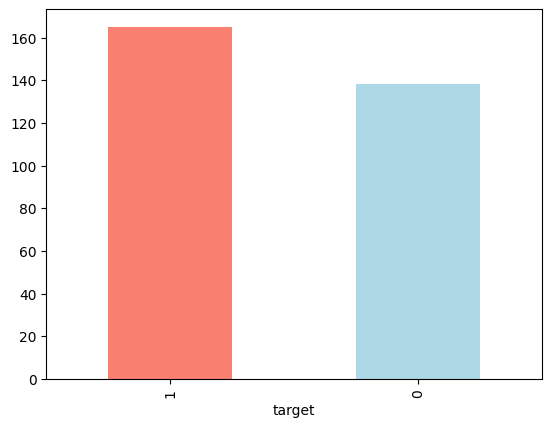

In [7]:
# Visualizing the "target" column in a form of a bar graph
# 1 = heart disease and 0 = no heart disease
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"])

In [8]:
# Checking if there are any missing values in the data frame
df.isnull().any()

,0
age,False
sex,False
cp,False
trestbps,False
chol,False
fbs,False
restecg,False
thalach,False
exang,False
oldpeak,False


For each column the output is false which means there are no missing values.

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Comparing Certain Features with the Target Column:**

In [10]:
# Comparing fbs column with target column:

# Checking how many people in the data set have diabetes (fbs = 1) and how many do not
df.fbs.value_counts()

,count
fbs,
0,258
1,45


* Based on the output above 258 people do not have diabetes and 45 people do have diabetes.

In [11]:
pd.crosstab(df.target, df.fbs)

fbs,0,1
target,,
0,116,22
1,142,23


* The output shows that, in this dataset, most individuals do not have diabetes but do have heart disease.
* Additionally, the number of people with diabetes who do not have heart disease is nearly equal to the number of people with diabetes who do have heart disease.



In [12]:
# Comparing "sex" column with "target" column:

# Checking the number of males and females that are part of the data
df.sex.value_counts()

,count
sex,
1,207
0,96


* Based on the output above it is clear that this data set consist more male than female.

In [13]:
# Compare "target" column with "sex" column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


* The output shows that if the participant in the dataset is a woman, there is approximately a 75% chance she has heart disease.

* If the participant is male, the existing dataset suggests a 45% chance of having heart disease.

* On average, the dataset indicates a 60% chance that anyone, regardless of gender, may have heart disease.

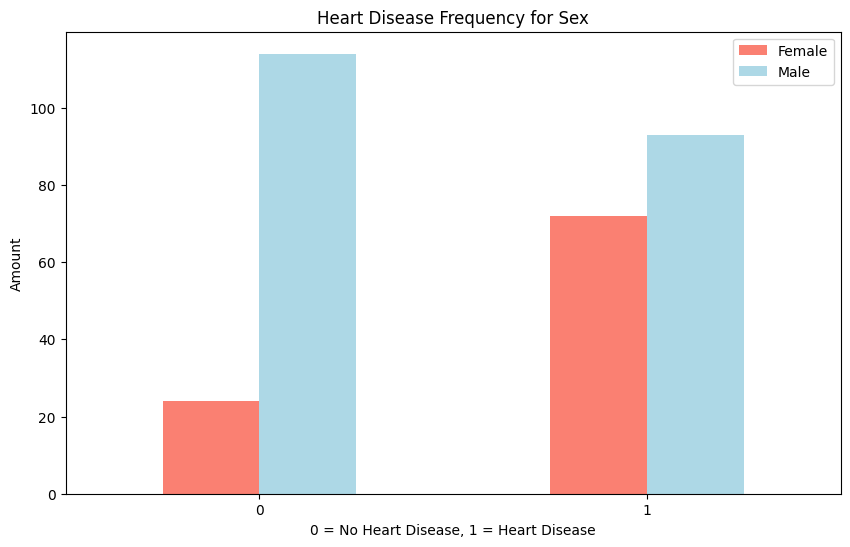

In [14]:
# Visualizing the crosstab of target and sex column
pd.crosstab(df.target, df.sex).plot(kind="bar", figsize=(10, 6), color=["salmon", "lightblue"])
plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Heart Disease, 1 = Heart Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"]);
plt.xticks(rotation=0);

In [15]:
# Compare "target" column with different Chest Pain Type
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


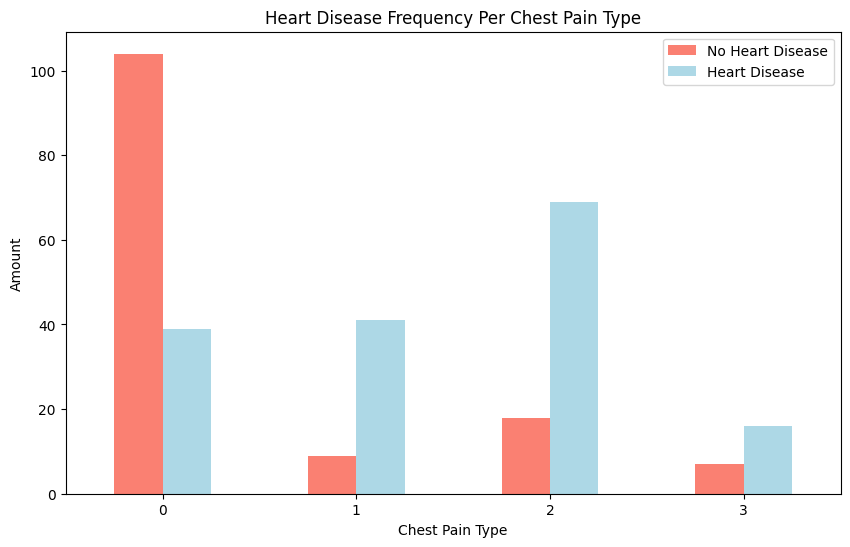

In [16]:
# Visualize target and cp column
pd.crosstab(df.cp, df.target).plot(kind="bar", figsize=(10, 6), color=["salmon", "lightblue"])
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount");
plt.legend(["No Heart Disease", "Heart Disease"])
plt.xticks(rotation=0);

**Correlation Matrix:**
* Each cell contains a correlation coefficient (value between -1 and 1)
* Values close to 1 indicate a strong positive correlation.
* Values close to -1 indicate a strong negative correlation.
* Values near 0 suggest no correlation.

In [17]:
# Building a Correlation Matrix

# .corr() method computes pairwise correlation of columns
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


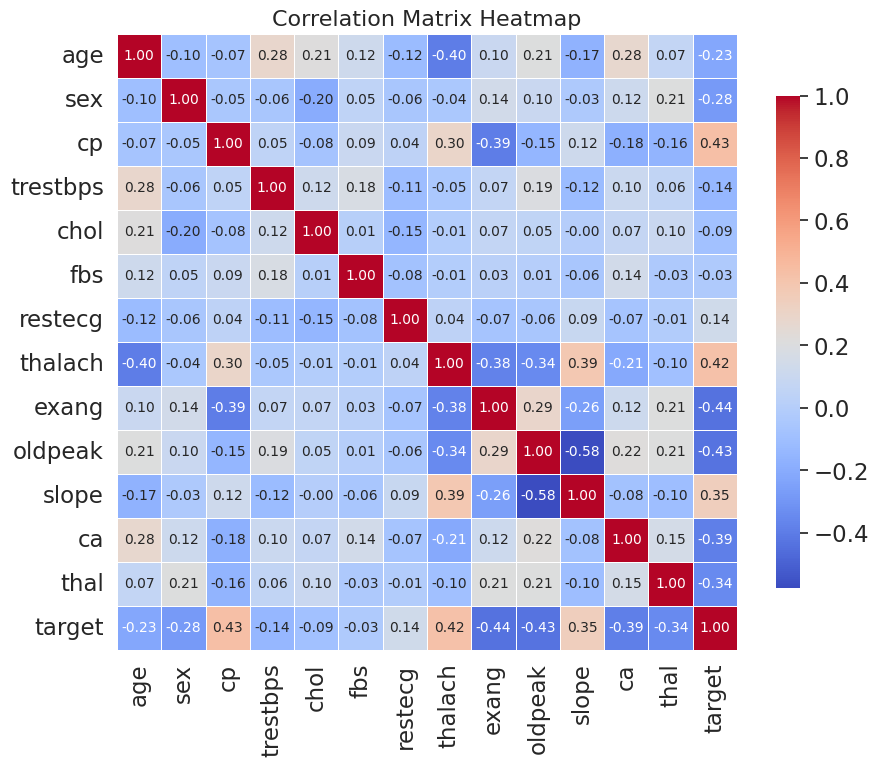

In [70]:
# Compute the correlation matrix
corr_matrix = df.corr()

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))  # Adjusted figure size for better spacing

# Create a heatmap with fine-tuned parameters
sns.heatmap(
    corr_matrix,
    annot=True,              # Annotate each cell with the correlation value
    linewidths=0.5,          # Line widths for gridlines
    fmt=".2f",               # Format the correlation values
    cmap="coolwarm",         # Color scheme
    annot_kws={"size": 10},  # Font size for annotations
    cbar_kws={"shrink": 0.8} # Adjust color bar size
)

# Add a title for context
ax.set_title("Correlation Matrix Heatmap", fontsize=16)

# Display the plot
plt.show()

## **Modelling**

**Split the Data:**

The purpose of having a training set and a test set is to evaluate whether the model can make accurate predictions on new, unseen data. The model should be tested on data it hasn't encountered during training, which is why we split the data into training and test sets. This ensures that the model's performance is assessed on its ability to generalize to new participants.

In [19]:
# Split data into X and y
X = df.drop("target", axis=1)
y = df["target"]

In [60]:
# Picking a specific random seed so everytime code runs the output is same
np.random.seed(42)

# Creating training and test sets
# test_size=0.2 indicates that 20% of data is used for test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

**Trying Different Models:**

  1. Logistic Regression
  2. K-Nearest Neighbours Classifier
  3. Random Forest Classifier
  4. Decision Tree

In [61]:
# Creating a distionary of all models
models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(), "Random Forest": RandomForestClassifier(), "Decision Tree": DecisionTreeClassifier()}

# Define a function to train, evaluate, and calculates score
def fit_and_evaluate(models, X_train, X_test, y_train, y_test, verbose=True):
    """
    Trains and evaluates multiple machine learning models.

    Args:
    models (dict): Dictionary of Scikit-Learn models to evaluate.
    X_train (array-like): Training features (input data).
    X_test (array-like): Testing features (input data).
    y_train (array-like): Training labels (target variable).
    y_test (array-like): Testing labels (target variable).
    verbose (bool): Whether to print progress for each model. Default is True.

    Returns:
    dict: A dictionary with model names as keys and evaluation metrics as values.
    """
    # Set a random seed for reproducibility
    np.random.seed(42)

    # Dictionary to store model evaluation metrics
    model_metrics = {}

    # Loop through each model in the dictionary
    for name, model in models.items():
        if verbose:
            print(f"Training and evaluating model: {name}...")

        # Train the model on the training data
        model.fit(X_train, y_train)

        # Predict on the test data
        y_pred = model.predict(X_test)

        # Compute evaluation metrics
        metrics = {
            "Score": model.score(X_test, y_test),  # Model's built-in score method
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        }

        # Store the metrics for the model
        model_metrics[name] = metrics

        if verbose:
            print(f"Completed: {name} | Metrics: {metrics}")

    return model_metrics

In [62]:
model_scores = fit_and_evaluate(models=models, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, verbose=True)
model_scores

Training and evaluating model: Logistic Regression...
Completed: Logistic Regression | Metrics: {'Score': 0.8852459016393442, 'Accuracy': 0.8852459016393442, 'Precision': 0.8787878787878788, 'Recall': 0.90625, 'F1 Score': 0.8923076923076924}
Training and evaluating model: KNN...
Completed: KNN | Metrics: {'Score': 0.6885245901639344, 'Accuracy': 0.6885245901639344, 'Precision': 0.6857142857142857, 'Recall': 0.75, 'F1 Score': 0.7164179104477612}
Training and evaluating model: Random Forest...


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed: Random Forest | Metrics: {'Score': 0.8360655737704918, 'Accuracy': 0.8360655737704918, 'Precision': 0.84375, 'Recall': 0.84375, 'F1 Score': 0.84375}
Training and evaluating model: Decision Tree...
Completed: Decision Tree | Metrics: {'Score': 0.8524590163934426, 'Accuracy': 0.8524590163934426, 'Precision': 0.9259259259259259, 'Recall': 0.78125, 'F1 Score': 0.847457627118644}


{'Logistic Regression': {'Score': 0.8852459016393442,
  'Accuracy': 0.8852459016393442,
  'Precision': 0.8787878787878788,
  'Recall': 0.90625,
  'F1 Score': 0.8923076923076924},
 'KNN': {'Score': 0.6885245901639344,
  'Accuracy': 0.6885245901639344,
  'Precision': 0.6857142857142857,
  'Recall': 0.75,
  'F1 Score': 0.7164179104477612},
 'Random Forest': {'Score': 0.8360655737704918,
  'Accuracy': 0.8360655737704918,
  'Precision': 0.84375,
  'Recall': 0.84375,
  'F1 Score': 0.84375},
 'Decision Tree': {'Score': 0.8524590163934426,
  'Accuracy': 0.8524590163934426,
  'Precision': 0.9259259259259259,
  'Recall': 0.78125,
  'F1 Score': 0.847457627118644}}

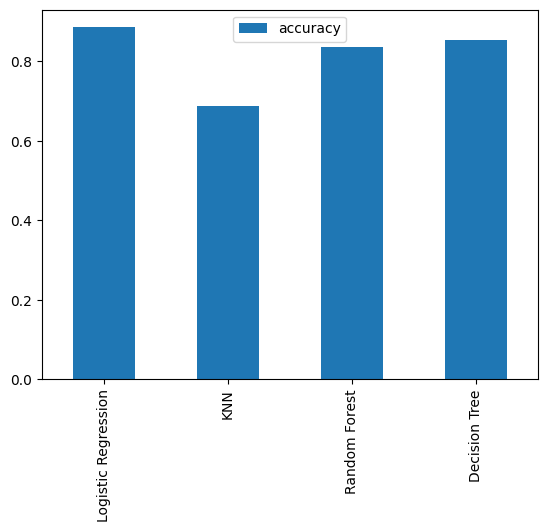

In [23]:
# Visualizing the score of each model

# Creating a dictionary with just model scores
results = {'Logistic Regression': 0.8852459016393442,
           'KNN': 0.6885245901639344,
           'Random Forest': 0.8360655737704918,
           'Decision Tree': 0.8524590163934426
}

# Graphing scores
compare = pd.DataFrame(results, index=["accuracy"])
compare.T.plot.bar();

Based on the results above, it is clear that the Logistic Regression and Decision Tree models performed the best. Since this is just the baseline, I still need to tune the hyperparameters. However, as the KNN model performed the worst, I will drop it and focus on improving the other three models.


**Hyperparameter Tuning with RandomizedSearchCV:**

Hyperparameter Grid:
* Definition: A hyperparameter grid is a list of all possible combinations of hyperparameters for a machine learning model.
* Purpose: It is used in grid search, a method for testing every combination of hyperparameters to find the best settings for a model.
* Process:
  * Train and evaluate the model for each combination in the grid.
  * Choose the combination that gives the best performance.

**Tune Logistic Regression Model:**

In [24]:
# First, create a hyperparameter grid for LogisticRegression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# Setup random seed
np.random.seed(42)

# The following code runs hyperparameter optimization on a Logistic Regression model. It randomly tests 40 different configurations of
# hyperparameters from the log_reg_grid, evaluates each using 5-fold cross-validation, and identifies the best configuration based on model
# performance.
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=40,
                                verbose=True)

# The following code trains the Logistic Regression model with the best parameters on the training data.
rs_log_reg.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=40. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=40,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [25]:
# Logistic Regression model with the best hyperparameters.
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 0.23357214690901212}

In [26]:
# The following code returns the performance of the best model found during the random search on the test data.
rs_log_reg.score(X_test, y_test)

0.8852459016393442

**Tune Decision Tree Model:**

In [27]:
# Create a hyperparameter grid for Decision Tree
dt_grid = {
    "max_depth": [None, 10, 20, 30, 40, 50],  # Control the depth of the tree
    "min_samples_split": np.arange(2, 20, 2),  # Minimum samples required to split an internal node
    "min_samples_leaf": np.arange(1, 20, 2),  # Minimum samples required to be at a leaf node
    "criterion": ["gini", "entropy"],  # Function to measure the quality of a split
    "max_features": [None, "sqrt", "log2"],  # Number of features to consider for the best split
    "splitter": ["best", "random"]  # Strategy used to split at each node
}

# Setup random seed
np.random.seed(42)

# Perform RandomizedSearchCV with Decision Tree
rs_dt = RandomizedSearchCV(DecisionTreeClassifier(),
                           param_distributions=dt_grid,
                           cv=5,
                           n_iter=20,  # Number of different configurations to test
                           verbose=True)

# Train the Decision Tree model with the best hyperparameters found
rs_dt.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'splitter': ['best', 'random']},
                   verbose=True)

In [28]:
# Decision Tree model with the best hyperparameters.
rs_dt.best_params_

{'splitter': 'best',
 'min_samples_split': 18,
 'min_samples_leaf': 11,
 'max_features': 'log2',
 'max_depth': None,
 'criterion': 'gini'}

In [29]:
# The following code returns the performance of the best model found during the random search on the test data.
rs_dt.score(X_test, y_test)

0.8688524590163934

**Tune Random Forest Classifier Model:**

In [30]:
# Creating a hyperparameter grid for RandomSearchClassifier
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

# Setup the random seed
np.random.seed(42)

# The following code runs hyperparameter optimization on a Random Forest Classifier model. It randomly tests 20 different configurations of
# hyperparameters from the log_reg_grid, evaluates each using 5-fold cross-validation, and identifies the best configuration based on model
# performance.
random_search_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

# The following code trains the Random Forest Classifier model with the best parameters on the training data.
random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [31]:
# Random Forest Classifier with best hyperparameters.
random_search_rf.best_params_

{'n_estimators': 210,
 'min_samples_split': 4,
 'min_samples_leaf': 19,
 'max_depth': 3}

In [32]:
# The following code returns the performance of the best model found during the random search on the test data.
random_search_rf.score(X_test, y_test)

0.8688524590163934

***After comparing the results of all the tuned models, the Logistic Regression model performed the best. Therefore, I will continue focusing on improving the Logistic Regression model further.***

**Hyperparameter Tuning with GridSearchCV**

Difference Between RandomizedSearchCV and GridSearchCV:
* GridSearchCV:
  * It tests every possible combination of the hyperparameters specified in the hyperparameter grid.
  * Example: If there are 3 possible values for Hyperparameter A and 4 possible values for Hyperparameter B, GridSearchCV will test all 12 combinations of (3 * 4 = 12).

* RandomizedSearchCV:
  * Instead of testing every possible combination, it samples a fixed number of combinations randomly from the specified hyperparameter space.
  * Example: Even if there 12 possible combinations like the GridSearchCV example, RandomizedSearchCV might randomly pick, say, 5 combinations to test.


In [33]:
# During RandomizedSearchCV 20 different choices for C were provided. Now, 30 different choices for C are provided.
# Since the method being used is GridSearch all 30 choices of C will be tested.
log_reg_grid = {"C": np.logspace(-4, 4, 30), "solver": ["liblinear"]}

# Setup grid hyperparameter search for Logistic Regression model.
grid_search_log_reg = GridSearchCV(LogisticRegression(), param_grid=log_reg_grid, cv=5, verbose=True)

# The following code trains the Logistic Regression model with the best parameters on the training data.
grid_search_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [34]:
# Logistic Regression model with best parameters
grid_search_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [35]:
# The following code returns the performance of the best model found during the grid search on the test data.
grid_search_log_reg.score(X_test, y_test)

0.8852459016393442

***Even after the grid search cross validation the score of the logistic regression model is the same.***

## **Evaluation**

#### ROC (Reciever Operating Characteristic) Curve:
* A graph showing trade-off between True Positive Rate (TPR) and False Positive Rate (FPR) at different classification thresholds.
* Helps visualize how well a model separates positive and negative classes.

#### AUC (Area Under the Curve):
* A single score summarizing the ROC curve performance.
* Range:
  * 1.0 = Perfect model
  * 0.5 = Random guessing
* Higher AUC means better classification ability.

#### Confusion Matrix Anatomy:
* True positive = model predicts 1 when truth is 1
* False positive = model predicts 1 when truth is 0
* True negative = model predicts 0 when truth is 0
* False negative = model predicts 0 when truth is 1

**ROC Curve and AUC Metric:**

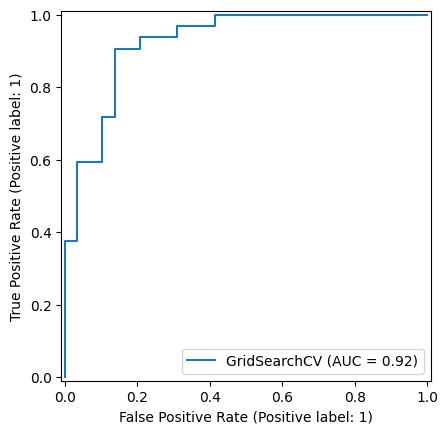

In [36]:
RocCurveDisplay.from_estimator(grid_search_log_reg, X_test, y_test);

**Confusion Matrix:**

In [37]:
y_predictions = grid_search_log_reg.predict(X_test)

In [38]:
print(confusion_matrix(y_test, y_predictions))

[[25  4]
 [ 3 29]]


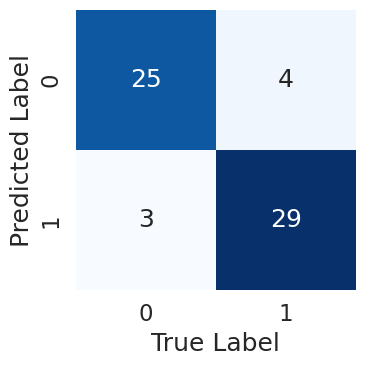

In [39]:
sns.set(font_scale=1.5)

def plotting_confusion_matrix(y_test, y_predictions):
  """
  Plots a confusion matrix using Seaborn's heatmap()
  """
  # Compute confusion matrix
  cm = confusion_matrix(y_test, y_predictions)

  # Create heatmap
  fig, ax = plt.subplots(figsize=(4, 4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
  ax.set_xlabel("True Label")
  ax.set_ylabel("Predicted Label")
  plt.tight_layout()

# Call the function
plotting_confusion_matrix(y_test, y_predictions)

* Model predicted 26 true negatives.
* Model predicted 4 false negatives.
* Model predicted 3 false positives.
* Model predicted 29 true positives.

**Classification Report**

A classification report helps evaluate how well a classification model is performing. It shows key metrics that represents how accurate the model is for each class. The main metrics include:
* **Accuracy:** Refers to the proportion of correct predictions made by the model compared to the number of predictions.
  * Accuracy = (Number of Correct Predictions)/(Total Number of Predictions)
* **Precision:** How many of the predicted positives are acctually correct. It is about minimizing false positives.
  * Precision = True Positives / (True Positives + False Positives)
* **Recall:** How many of the actual positives were correctly identified by the model. It is about minimizing false negatives.
  * Recall = True Positives / (True Positives + False Negatives)
* **F1-Score:** A balance between precision and recall, combining both into a single number to give a better overall picture of the model's performance.
  * F1 = 2 * ((Precision*Recall)/(Precision+Recall))

**Creating a Classification Report using cross-validation model:**


In [40]:
# Logistic Regression model with the best hyperparameters
grid_search_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [41]:
# Create a new Logistic Regression model object using the best hyperparameters
new_classifier = LogisticRegression(C=0.20433597178569418, solver="liblinear")

In [42]:
# Accuracy Metrics:

# The following code performs 5-fold cross-validation on a classifier (new_classifier) using the feature set (X) and target (y). It splits the
# data into 5 parts, trains the model 5 times, and evaluates its accuracy on each fold. The accuracy scores for each fold are returned as an
# array (cv_accuracy).
cv_accuracy = cross_val_score(new_classifier, X, y, cv=5, scoring="accuracy")
cv_accuracy

array([0.81967213, 0.90163934, 0.86885246, 0.88333333, 0.75      ])

In [43]:
# Find the mean of the cv_accuracy array
cv_accuracy = np.mean(cv_accuracy)
cv_accuracy

0.8446994535519124

In [44]:
# Precision Metrics:
cv_precision = cross_val_score(new_classifier, X, y, cv=5, scoring="precision")
cv_precision

array([0.775     , 0.88571429, 0.85714286, 0.86111111, 0.725     ])

In [45]:
# Find the mean of the cv_precision array
cv_precision = np.mean(cv_precision)
cv_precision

0.8207936507936507

In [46]:
# Recall Metrics:
cv_recall = cross_val_score(new_classifier, X, y, cv=5, scoring="recall")
cv_recall

array([0.93939394, 0.93939394, 0.90909091, 0.93939394, 0.87878788])

In [47]:
# Find the mean of the cv_recall array
cv_recall = np.mean(cv_recall)
cv_recall

0.9212121212121213

In [48]:
# f1-score Metrics:
cv_f1_score = cross_val_score(new_classifier, X, y, cv=5, scoring="f1")
cv_f1_score

array([0.84931507, 0.91176471, 0.88235294, 0.89855072, 0.79452055])

In [49]:
# Find the mean of the cv_f1_score array
cv_f1_score = np.mean(cv_f1_score)
cv_f1_score

0.8673007976269721

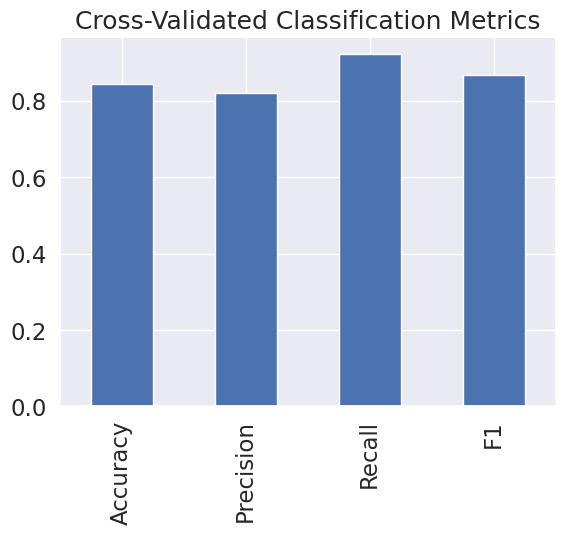

In [50]:
# Visualize cross-validated Metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_accuracy, "Precision": cv_precision, "Recall": cv_recall, "F1": cv_f1_score}, index=[0])
cv_metrics.T.plot.bar(title="Cross-Validated Classification Metrics", legend=False);

## **Feature Importance**

In [51]:
# Logistic Regression model with the best hyperparameters
grid_search_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [65]:
# Create a instance of Logistic Regression using best parameters
final_model = LogisticRegression(C=0.20433597178569418, solver="liblinear")

In [66]:
# Find patterns new_model using the training dataset
final_model.fit(X_train, y_train);

In [67]:
# Check coefficient -> how each feature is contributing to the target
final_model.coef_

array([[ 0.00320769, -0.86062049,  0.66001432, -0.01155971, -0.00166496,
         0.04017236,  0.31603405,  0.02458922, -0.60470171, -0.56795456,
         0.45085392, -0.63733328, -0.67555094]])

In [68]:
# Match coef's of features with their corresponding column
dictionary = dict(zip(df.columns, list(final_model.coef_[0])))
dictionary

{'age': 0.0032076883508599633,
 'sex': -0.8606204883695241,
 'cp': 0.660014324982524,
 'trestbps': -0.01155970600550047,
 'chol': -0.0016649614843449207,
 'fbs': 0.040172360271308105,
 'restecg': 0.31603405294617176,
 'thalach': 0.02458922341328129,
 'exang': -0.604701713592625,
 'oldpeak': -0.5679545646616215,
 'slope': 0.4508539209693025,
 'ca': -0.6373332766360461,
 'thal': -0.6755509369619848}

* The most important features are Sex, Cp, Oldpeak, Ca, and Thal because they have the largest absolute coefficients.
* Features with lower importance include Age, Trestbps, and Chol, which have smaller coefficients.